## 학습 단계 (code 기준)
1. library 가져오기
2. GPU 사용 설정하고 random value를 위한 seed 설정
3. 학습에 사용되는 parameter 설정 : learning rate, training epochs, batch size 등
4. 데이터셋 가져오고 로더 만들기
5. 학습 모델(클래스) 만들기
6. loss 함수 (criterion) 선택하고 최적화 도구 선택 (optimizer)
7. 모델 학습 및 loss check (criterion의 output)
8. 학습된 모델 성능 확인 

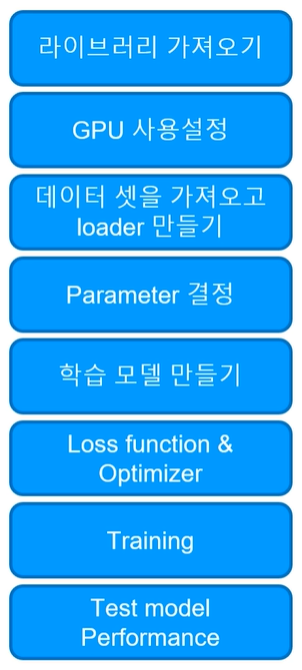

### 작성할 cnn 구조
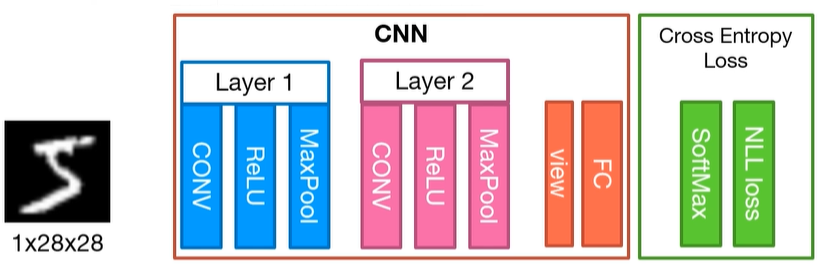


- (Layer 1) convolution layer = (in_c=1, out=32, kernel_size=3, stride=1, padding=1)
- (Layer 1) MaxPool layer = (kernel_size=2, stride=2)

- (Layer 2) convolution layer = (in_c=32, out_c=64, kernel_size=3, stride=1, padding=1)
- (Layer 2) MaxPool layer = (kernel_size=2, stride=2)

- 결과 shape이 64x7x7
- view 진행 : batch size x [7, 7, 64] => batch size x [3136]
- => code : out = out.view(out.size(0), -1) -> torch.Size([1, 3136]) 됨 

- fully connected layer : input = 3136, output = 10

In [24]:
import torch
import torchvision.datasets as dsets
import torchvision.transforms as transforms

import torch.nn.init
import torch.nn as nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)

In [25]:
torch.cuda.is_available()

False

In [26]:
# parameters
learning_rate = 0.001
training_epochs = 15
batch_size =100

In [27]:
# MNIST dataset

mnist_train = dsets.MNIST(root="MNIST_data/", 
                          train=True,
                          transform=transforms.ToTensor(),
                          download=True)
mnist_test = dsets.MNIST(root="MNIST_data/",
                         train=False,
                         transform=transforms.ToTensor(),
                         download=True)

In [28]:
data_loader = torch.utils.data.DataLoader(dataset=mnist_train,
                                          batch_size=batch_size,
                                          shuffle=True,
                                          drop_last = True)

In [29]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc = nn.Linear(7 * 7 * 64, 10, bias=True)

        torch.nn.init.xavier_uniform_(self.fc.weight)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)

        return out

In [30]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

In [31]:
# training

total_batch = len(data_loader)
for epoch in range(training_epochs):
    avg_cost = 0

    for X, Y in data_loader:
        X = X.to(device)
        Y = Y.to(device)

        optimizer.zero_grad()
        hypothesis = model(X)

        cost = criterion(hypothesis, Y)
        cost.backward()
        optimizer.step()

        avg_cost += cost / total_batch
    print('[Epoch {}] cost = {}'.format(epoch + 1, avg_cost))
print("Learning finished!")

[Epoch 1] cost = 0.22565427422523499
[Epoch 2] cost = 0.06305725127458572
[Epoch 3] cost = 0.04624796286225319
[Epoch 4] cost = 0.03746913745999336
[Epoch 5] cost = 0.031465720385313034
[Epoch 6] cost = 0.026178603991866112
[Epoch 7] cost = 0.02201269194483757
[Epoch 8] cost = 0.018226241692900658
[Epoch 9] cost = 0.016448169946670532
[Epoch 10] cost = 0.013246809132397175
[Epoch 11] cost = 0.009985717944800854
[Epoch 12] cost = 0.00974790658801794
[Epoch 13] cost = 0.008483914658427238
[Epoch 14] cost = 0.006924247369170189
[Epoch 15] cost = 0.006376168690621853
Learning finished!


In [32]:
with torch.no_grad():
    X_test = mnist_test.test_data.view(len(mnist_test), 1, 28, 28).float().to(device)
    Y_test = mnist_test.test_labels.to(device)

    prediction = model(X_test)
    correct_prediction = torch.argmax(prediction, 1) == Y_test
    accuracy = correct_prediction.float().mean()
    print("Accuracy: ", accuracy.item())

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\datasets\mnist.py:81: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\datasets\mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


Accuracy:  0.9873999953269958


### 레이어 더 추가하기

In [ ]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.layer4 = nn.Linear(4 * 4* 128, 625, bias=True)

        self.fc = nn.Linear(625, 10, bias=True)

        torch.nn.init.xavier_uniform_(self.fc.weight)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = out.view(out.size(0), -1)
        out = self.layer4(out)
        out = self.fc(out)

        return out

In [34]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

# training

total_batch = len(data_loader)
for epoch in range(training_epochs):
    avg_cost = 0

    for X, Y in data_loader:
        X = X.to(device)
        Y = Y.to(device)

        optimizer.zero_grad()
        hypothesis = model(X)

        cost = criterion(hypothesis, Y)
        cost.backward()
        optimizer.step()

        avg_cost += cost / total_batch
    print('[Epoch {}] cost = {}'.format(epoch + 1, avg_cost))
print("Learning finished!")

with torch.no_grad():
    X_test = mnist_test.test_data.view(len(mnist_test), 1, 28, 28).float().to(device)
    Y_test = mnist_test.test_labels.to(device)

    prediction = model(X_test)
    correct_prediction = torch.argmax(prediction, 1) == Y_test
    accuracy = correct_prediction.float().mean()
    print("Accuracy: ", accuracy.item())

AttributeError: module 'torch.nn' has no attribute 'Seqeuntial'